### 6.1. Setup

Install required text processing libraries for the example

In [14]:
# Import the core NLTK library
import nltk

# Import English stopwords corpus helper
from nltk.corpus import stopwords

# Import the WordNet lemmatizer class
from nltk.stem import WordNetLemmatizer

# NLP library used for tokenization, stopwords, and lemmatization

# Download the stopwords corpus (required before using stopwords.words)
nltk.download('stopwords')

# Import stopwords again (already imported above; kept as in original code)
from nltk.corpus import stopwords

# Download the Punkt tokenizer (required for word_tokenize)
nltk.download('punkt')

# Download the WordNet lexical database (required for lemmatization)
nltk.download('wordnet')

# Import the lemmatizer class again (already imported above; kept as in original code)
from nltk.stem import WordNetLemmatizer

# Create a lemmatizer instance for later text normalization
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### 6.2. Creating Text Representations

Text data needs to be converted to numeric representations before they can be used to train deep learning models. The Spam classification feature data is converted to TF-IDF vectors and the target variable is converted to one-hot encoding.

In [15]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

#Load Spam Data and review content
spam_data = pd.read_csv("Spam-Classification.csv")

print("\nLoaded Data :\n------------------------------------")
print(spam_data.head())

#Separate feature and target data
spam_classes_raw = spam_data["CLASS"]
spam_messages = spam_data["SMS"]



Loaded Data :
------------------------------------
  CLASS                                                SMS
0   ham   said kiss, kiss, i can't do the sound effects...
1   ham      &lt;#&gt; ISH MINUTES WAS 5 MINUTES AGO. WTF.
2  spam  (Bank of Granite issues Strong-Buy) EXPLOSIVE ...
3  spam  * FREE* POLYPHONIC RINGTONE Text SUPER to 8713...
4  spam  **FREE MESSAGE**Thanks for using the Auction S...


In [16]:

import nltk
import tensorflow as tf

#Custom tokenizer to remove stopwords and use lemmatization
def customtokenize(str):
    #Split string as tokens
    tokens=nltk.word_tokenize(str)
    #Filter for stopwords
    nostop = list(filter(lambda token: token not in stopwords.words('english'), tokens))
    #Perform lemmatization
    lemmatized=[lemmatizer.lemmatize(word) for word in nostop ]
    return lemmatized

from sklearn.feature_extraction.text import TfidfVectorizer

#Build a TF-IDF Vectorizer model
vectorizer = TfidfVectorizer(tokenizer=customtokenize)

#Transform feature input to TF-IDF
tfidf=vectorizer.fit_transform(spam_messages)
#Convert TF-IDF to numpy array
tfidf_array = tfidf.toarray()

#Build a label encoder for target variable to convert strings to numeric values.
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()
spam_classes = label_encoder.fit_transform(
                                spam_classes_raw)

#Convert target to one-hot encoding vector
spam_classes = tf.keras.utils.to_categorical(spam_classes,2)

print("TF-IDF Matrix Shape : ", tfidf.shape)
print("One-hot Encoding Shape : ", spam_classes.shape)

X_train,X_test,Y_train,Y_test = train_test_split( tfidf_array, spam_classes, test_size=0.10)

c:\Users\kumar\anaconda3\envs\deep-learning-gs\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TF-IDF Matrix Shape :  (1500, 4566)
One-hot Encoding Shape :  (1500, 2)


### 6.3. Building and Evaluating the Model

In [17]:
from tensorflow import keras
from tensorflow.keras import optimizers
from tensorflow.keras.regularizers import l2

#Setup Hyper Parameters for building the model
# Number of output classes (ham, spam)
NB_CLASSES = 2

# Number of neurons in each hidden dense layer
N_HIDDEN = 32

# Create a sequential neural network model for spam classification
model = keras.Sequential(name="spam_classifier")

# Define input layer using the TF-IDF feature size
model.add(keras.layers.Input(shape=(X_train.shape[1],), name="Input-Layer"))

# Add first hidden layer with ReLU activation and L2 regularization
model.add(keras.layers.Dense(
  N_HIDDEN,
  name="Hidden-Layer-1",
  activation="relu",
  kernel_regularizer=l2(0.001)
))

# Add second hidden layer with ReLU activation and L2 regularization
model.add(keras.layers.Dense(
  N_HIDDEN,
  name="Hidden-Layer-2",
  activation="relu",
  kernel_regularizer=l2(0.001)
))

# Add output layer with softmax activation for 2-class prediction
model.add(keras.layers.Dense(
  NB_CLASSES,
  name="Output-Layer",
  activation="softmax"
))

# Compile model with Adam optimizer, categorical crossentropy loss, and accuracy metric
model.compile(
  optimizer=optimizers.Adam(),
  loss="categorical_crossentropy",
  metrics=["accuracy"]
)

# Print model architecture summary
model.summary()


Model: "spam_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden-Layer-1 (Dense)          │ (None, 32)             │       146,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-Layer-2 (Dense)          │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output-Layer (Dense)            │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,266 (575.26 KB)

 Trainable params: 147,266 (575.26 KB)

 Non-trainable params: 0 (0.00 B)


Training Progress:
------------------------------------
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5407 - loss: 0.7792 - val_accuracy: 0.6444 - val_loss: 0.7618
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7917 - loss: 0.7486 - val_accuracy: 0.7815 - val_loss: 0.7362
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9343 - loss: 0.7169 - val_accuracy: 0.8444 - val_loss: 0.7082
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9593 - loss: 0.6809 - val_accuracy: 0.8593 - val_loss: 0.6776
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9657 - loss: 0.6402 - val_accuracy: 0.8852 - val_loss: 0.6448
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9722 - loss: 0.5960 - val_accuracy: 0.8889 - val_loss: 0.6099
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9787 - loss: 0.5486 - val_accuracy: 0.8926 - val_loss: 0.5739
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9806 

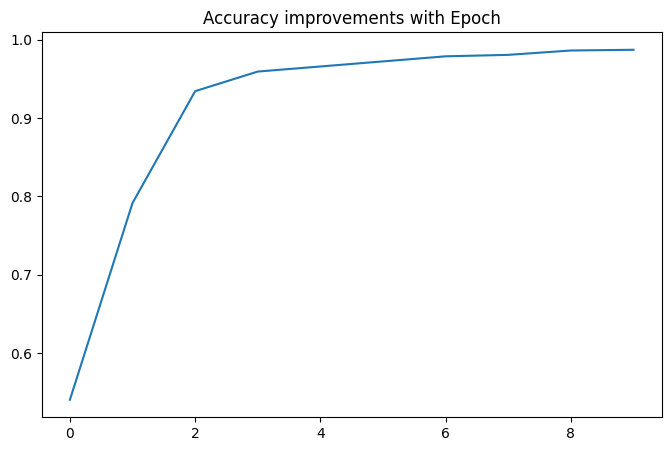


Evaluation against Test Dataset :
------------------------------------
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8533 - loss: 0.4971 


[0.49714142084121704, 0.8533333539962769]

In [18]:
#Make it verbose so we can see the progress
VERBOSE=1

#Setup Hyper Parameters for training
BATCH_SIZE=256
EPOCHS=10
VALIDATION_SPLIT=0.2

print("\nTraining Progress:\n------------------------------------")

history=model.fit(X_train,
          Y_train,
          batch_size=BATCH_SIZE,
          epochs=EPOCHS,
          verbose=VERBOSE,
          validation_split=VALIDATION_SPLIT)

print("\nAccuracy during Training :\n------------------------------------")
import matplotlib.pyplot as plt

pd.DataFrame(history.history)["accuracy"].plot(figsize=(8, 5))
plt.title("Accuracy improvements with Epoch")
plt.show()

print("\nEvaluation against Test Dataset :\n------------------------------------")
model.evaluate(X_test,Y_test)

### 6.4. Predicting for Text

In [19]:
#Predict for multiple samples using batch processing

#Convert input into IF-IDF vector using the same vectorizer model
predict_tfidf=vectorizer.transform(["FREE entry to a fun contest",
                                    "Yup I will come over"]).toarray()

print(predict_tfidf.shape)

#Predict using model
prediction=np.argmax( model.predict(predict_tfidf), axis=1 )
print("Prediction Output:" , prediction)

#Print prediction classes
print("Prediction Classes are ", label_encoder.inverse_transform(prediction))

(2, 4566)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction Output: [1 0]
Prediction Classes are  ['spam' 'ham']
